In [1]:
# TASK 1: Term Deposit Subscription Prediction
# Dataset: Bank Marketing (UCI)
# Goal: Predict if customer will subscribe to term deposit

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

# SHAP for Explainable AI
import shap

# Suppress warnings for clean output
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Install SHAP
# It explains WHY the model made each prediction
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)
print("SHAP installed!")

SHAP installed!


In [3]:
#STEP 1: LOAD DATASET
url = "https://raw.githubusercontent.com/selva86/datasets/master/bank-full.csv"
df = pd.read_csv(url, sep=';')   # This file uses semicolon as separator

# Basic exploration
print("Shape:", df.shape)           # Rows x Columns
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())            # Check for nulls

print("\nTarget Column Distribution:")
print(df['y'].value_counts())       # How many yes vs no
print(df['y'].value_counts(normalize=True) * 100)  # Percentage




Shape: (41188, 21)

Columns:
 ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

First 5 rows:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may   

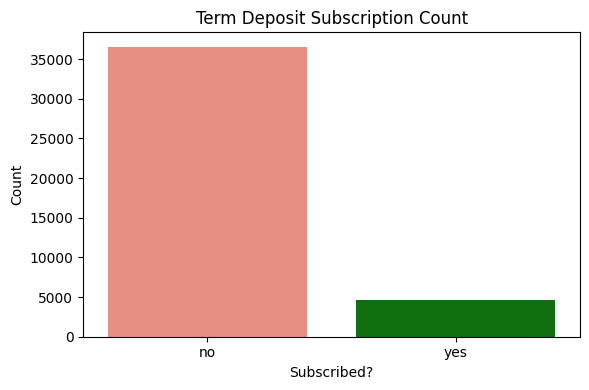

In [4]:
#EDA Visualizations
#STEP 2: EXPLORATORY DATA ANALYSIS (EDA)

# --- Plot 1: Target Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y',
              hue='y',
              palette={'yes': 'green', 'no': 'salmon'},
              legend=False)
plt.title('Term Deposit Subscription Count')
plt.xlabel('Subscribed?')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

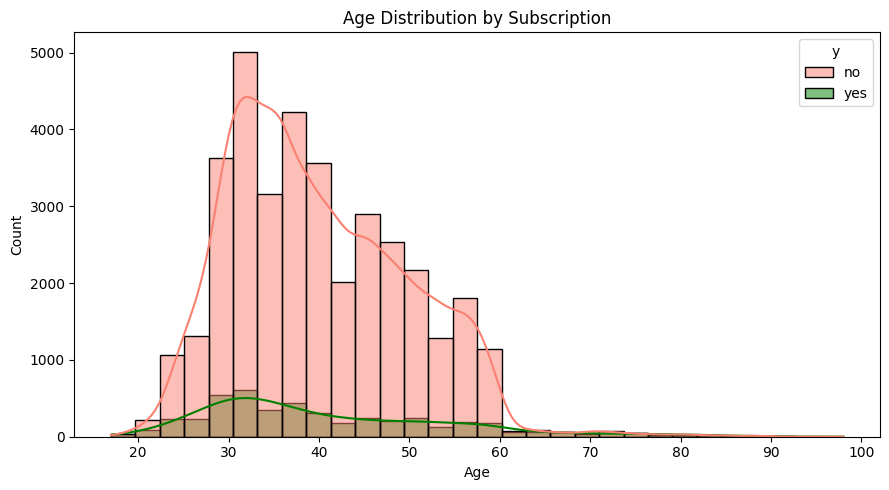

In [5]:
# --- Plot 2: Age vs Subscription ---
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='age', hue='y',
             bins=30, kde=True,
             palette={'yes': 'green', 'no': 'salmon'})
plt.title('Age Distribution by Subscription')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

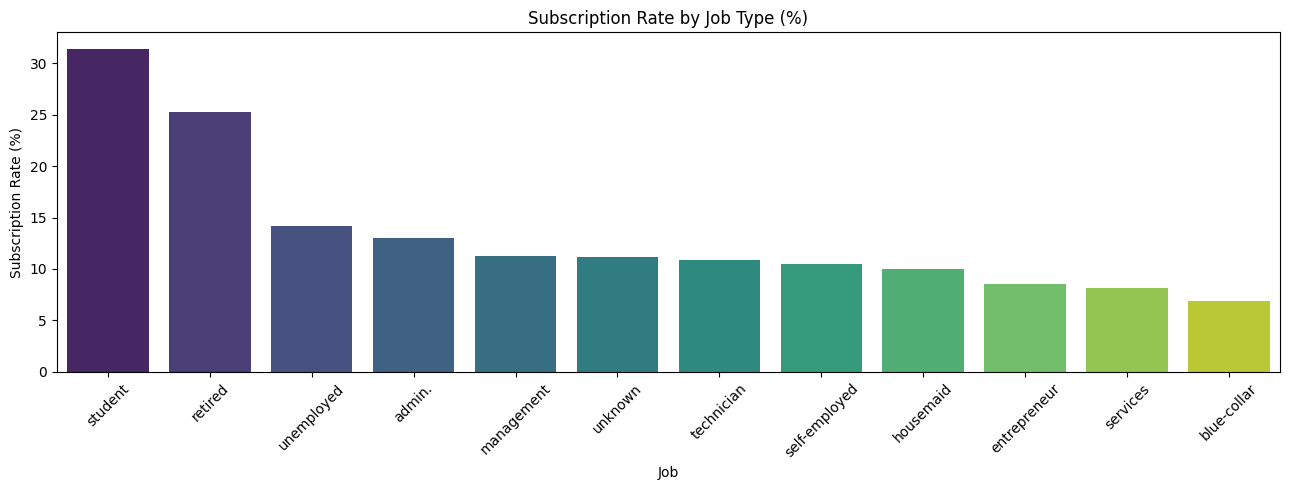

In [6]:
# --- Plot 3: Job Type vs Subscription Rate ---
plt.figure(figsize=(13, 5))
job_rate = df.groupby('job')['y'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=False)

sns.barplot(x=job_rate.index, y=job_rate.values,
            hue=job_rate.index, palette='viridis', legend=False)
plt.title('Subscription Rate by Job Type (%)')
plt.xlabel('Job')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

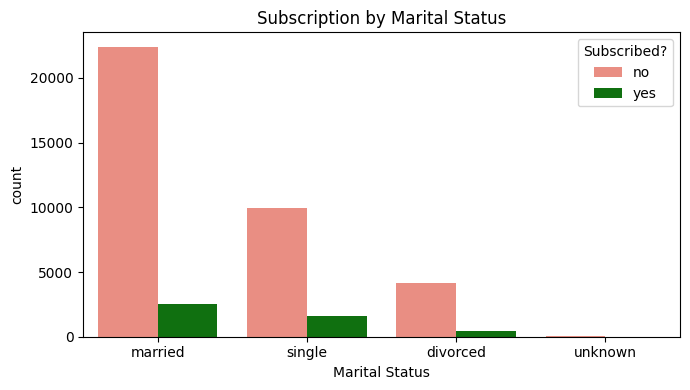

In [7]:
# --- Plot 4: Marital Status vs Subscription ---
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='marital', hue='y',
              palette={'yes': 'green', 'no': 'salmon'})
plt.title('Subscription by Marital Status')
plt.xlabel('Marital Status')
plt.legend(title='Subscribed?')
plt.tight_layout()
plt.show()

In [8]:
#STEP 3: DATA CLEANING & ENCODING
df_model = df.copy()   # Work on a copy, keep original safe

# Check all text (object) columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Encode target column first
# yes → 1,  no → 0
df_model['y'] = df_model['y'].map({'yes': 1, 'no': 0})

# Remove target from cat_cols list before encoding
cat_cols = [col for col in cat_cols if col != 'y']

# Label Encode all remaining text columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"Encoded: {col}")

print("\nAll columns encoded!")
print(df_model.head())

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']
Encoded: job
Encoded: marital
Encoded: education
Encoded: default
Encoded: housing
Encoded: loan
Encoded: contact
Encoded: month
Encoded: day_of_week
Encoded: poutcome

All columns encoded!
   age  job  marital  education  default  housing  loan  contact  month  \
0   56    3        1          0        0        0     0        1      6   
1   57    7        1          3        1        0     0        1      6   
2   37    7        1          3        0        2     0        1      6   
3   40    0        1          1        0        0     0        1      6   
4   56    7        1          3        0        0     2        1      6   

   day_of_week  ...  campaign  pdays  previous  poutcome  emp.var.rate  \
0            1  ...         1    999         0         1           1.1   
1            1  ...         1    999         0         1           1.1   
2 

In [9]:
# ── STEP 4: SPLIT DATA ────────────────────────────────────

X = df_model.drop('y', axis=1)    # Features (everything except target)
y = df_model['y']                  # Target

# 80% training, 20% testing
# stratify=y → keeps same yes/no ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Yes in train: ", y_train.sum())
print("Yes in test:  ", y_test.sum())

# ── STEP 5: SCALE FEATURES ───────────────────────────────
# StandardScaler brings all values to same range
# Important for Logistic Regression

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit on train only
X_test_sc  = scaler.transform(X_test)        # Apply same scale to test

X_train shape: (32950, 20)
X_test shape:  (8238, 20)
Yes in train:  3712
Yes in test:   928


In [10]:
#STEP 6: TRAIN MODELS
# --- Model 1: Logistic Regression ---
# class_weight='balanced' handles imbalanced data
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'   # Fixes imbalanced dataset problem
)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("=" * 40)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr, zero_division=0))
print(classification_report(y_test, y_pred_lr, zero_division=0))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8568827385287692
F1 Score: 0.5861705861705861
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      7310
           1       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238



In [11]:
# --- Model 2: Random Forest ---
# Does NOT need scaling
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))
print(classification_report(y_test, y_pred_rf, zero_division=0))

RANDOM FOREST RESULTS
Accuracy: 0.91854819130857
F1 Score: 0.5622961513372472
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      7310
           1       0.71      0.46      0.56       928

    accuracy                           0.92      8238
   macro avg       0.82      0.72      0.76      8238
weighted avg       0.91      0.92      0.91      8238



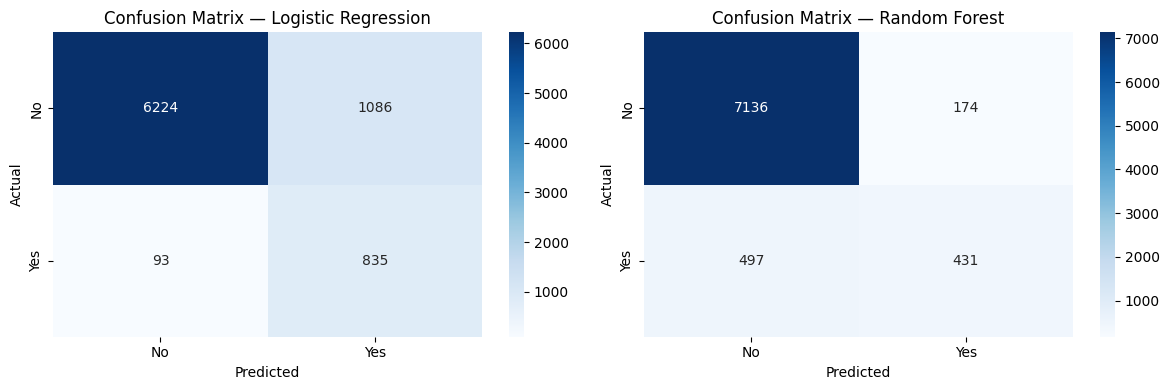

In [12]:
# ─ STEP 7: CONFUSION MATRIX

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

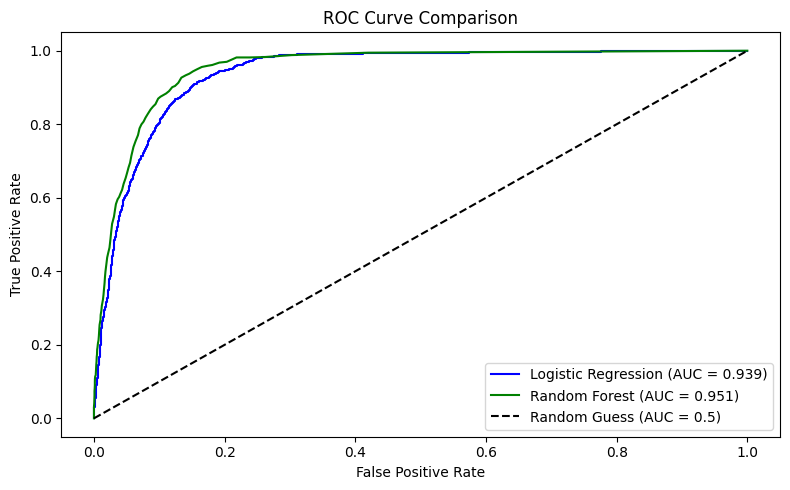

LR  AUC: 0.9387
RF  AUC: 0.9508


In [13]:
# ── STEP 8: ROC CURVE ────────────────────────────────────
# ROC = Receiver Operating Characteristic
# Shows tradeoff between catching true positives vs false alarms
# AUC (Area Under Curve) → closer to 1.0 = better model

plt.figure(figsize=(8, 5))

# Logistic Regression ROC
lr_probs  = lr.predict_proba(X_test_sc)[:, 1]  # Probability of yes
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
auc_lr = roc_auc_score(y_test, lr_probs)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='blue')

# Random Forest ROC
rf_probs  = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
auc_rf = roc_auc_score(y_test, rf_probs)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green')

# Baseline (random guessing)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

print(f"LR  AUC: {auc_lr:.4f}")
print(f"RF  AUC: {auc_rf:.4f}")
# Higher AUC = better model

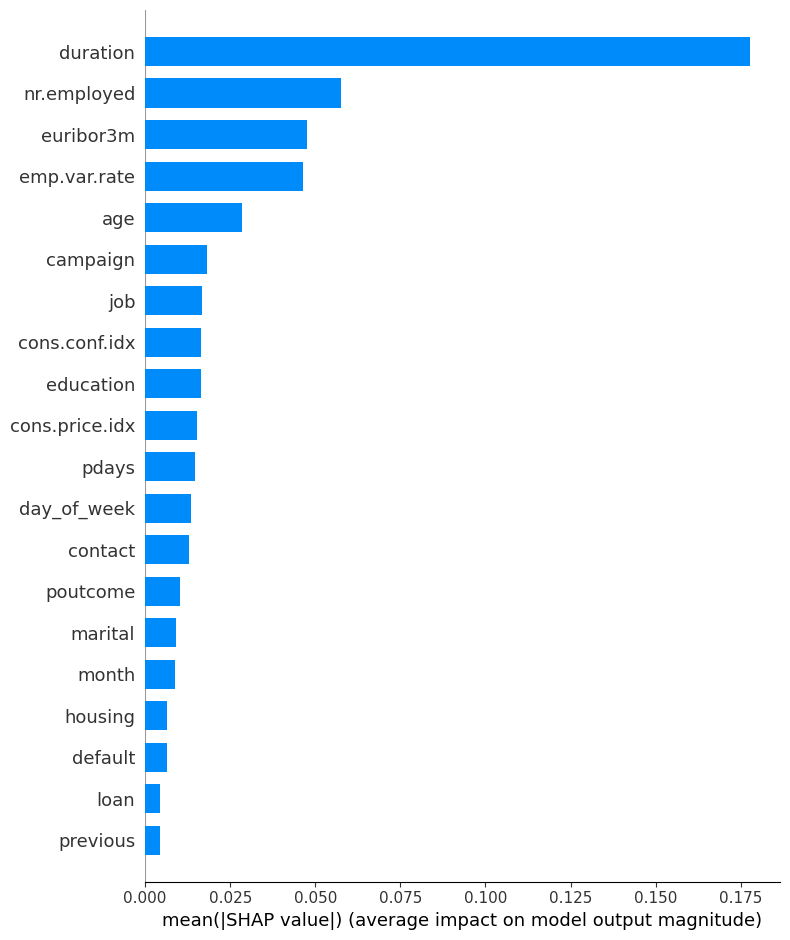

In [16]:
# ── STEP 9: SHAP — EXPLAINABLE AI ────────────────────────
# SHAP explains WHY the model made each prediction
# Each feature gets a + or - value showing its contribution

# Create SHAP explainer using Random Forest
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for test set
# Use first 100 rows for speed
X_test_df = pd.DataFrame(X_test, columns=X.columns)
shap_values = explainer.shap_values(X_test_df[:100])

# --- Plot 1: Summary Plot (overall feature importance) ---
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],   # Index 1 = class "yes"
    X_test_df[:100],
    plot_type='bar',
    show=True
)
# INSIGHT: Shows which features matter MOST overall



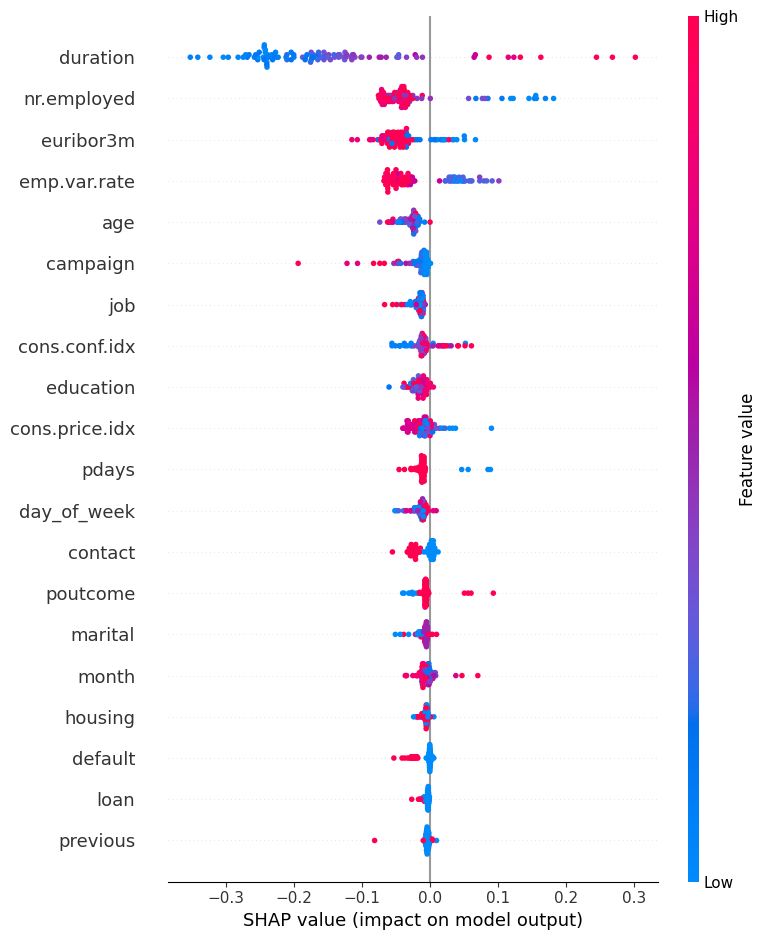

In [17]:
# --- Plot 2: Beeswarm (direction of impact) ---
plt.figure()
shap.summary_plot(
    shap_values[:, :, 1],
    X_test_df[:100],
    show=True
)
# Red = high value, Blue = low value
# Right side = pushes towards YES, Left = pushes towards NO

Explaining 5 individual predictions...

--- Customer #1 ---
Actual:    NO
Predicted: NO


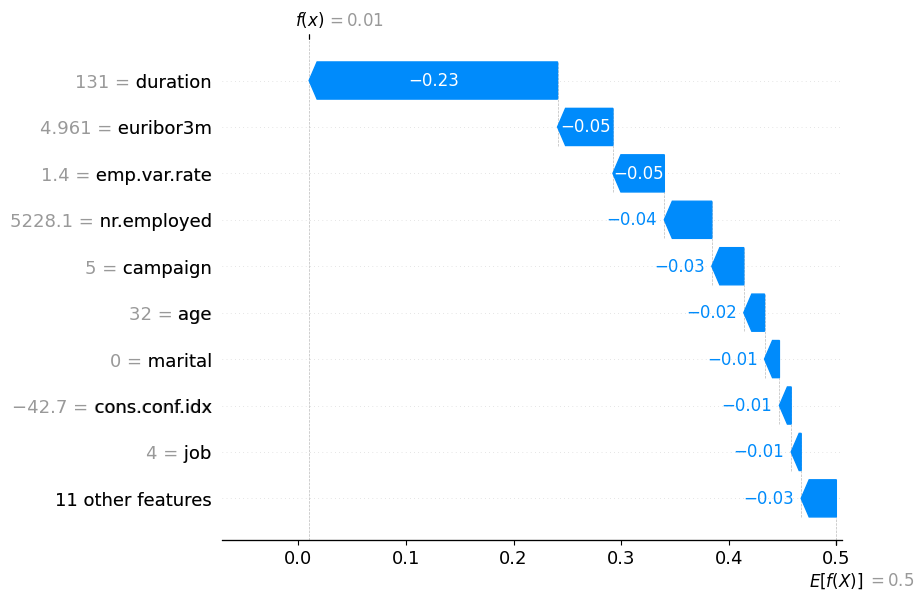


--- Customer #2 ---
Actual:    NO
Predicted: NO


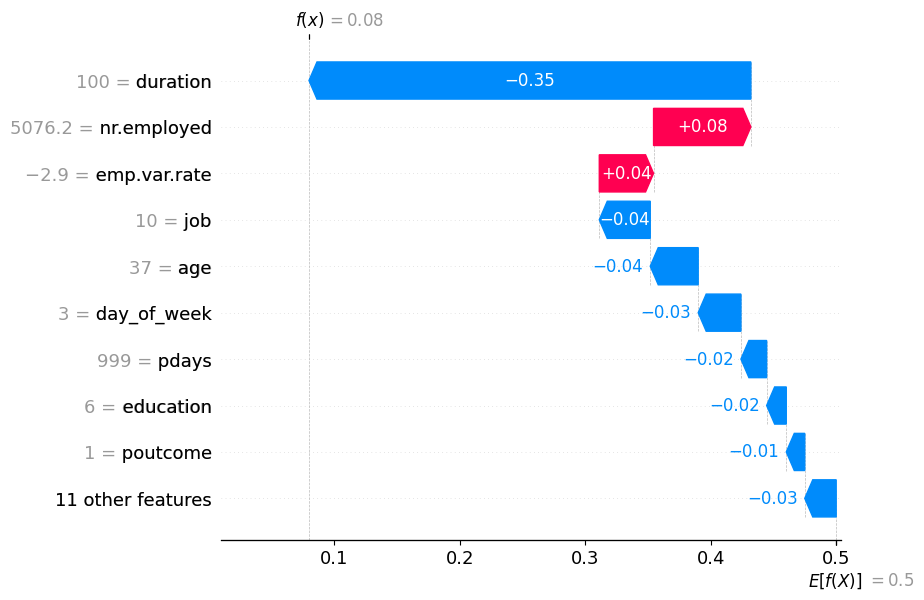


--- Customer #3 ---
Actual:    NO
Predicted: NO


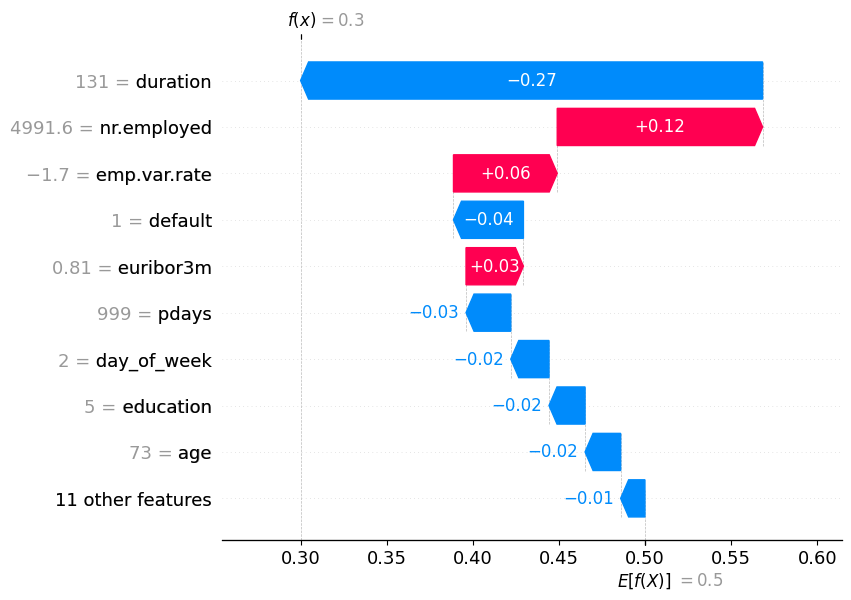


--- Customer #4 ---
Actual:    NO
Predicted: NO


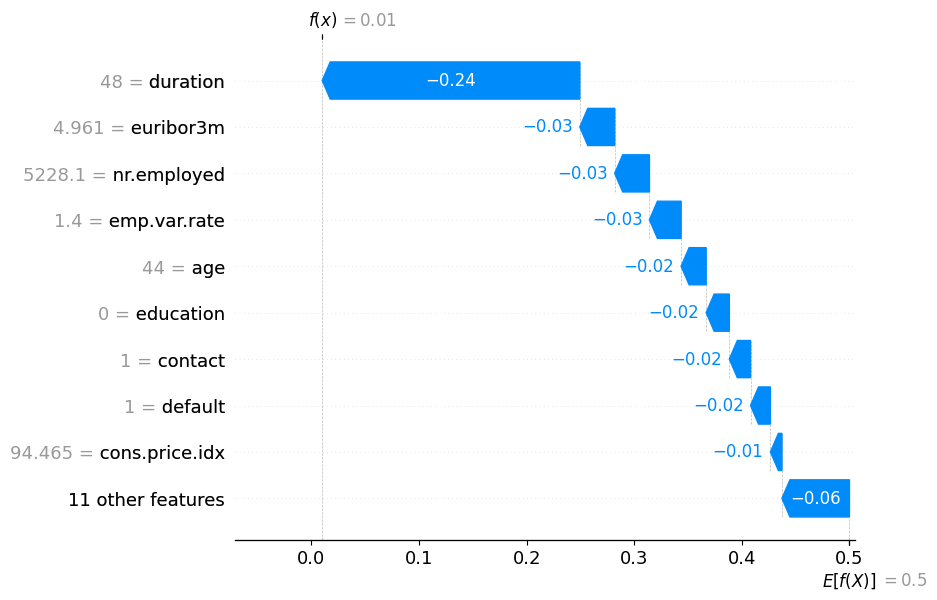


--- Customer #5 ---
Actual:    NO
Predicted: NO


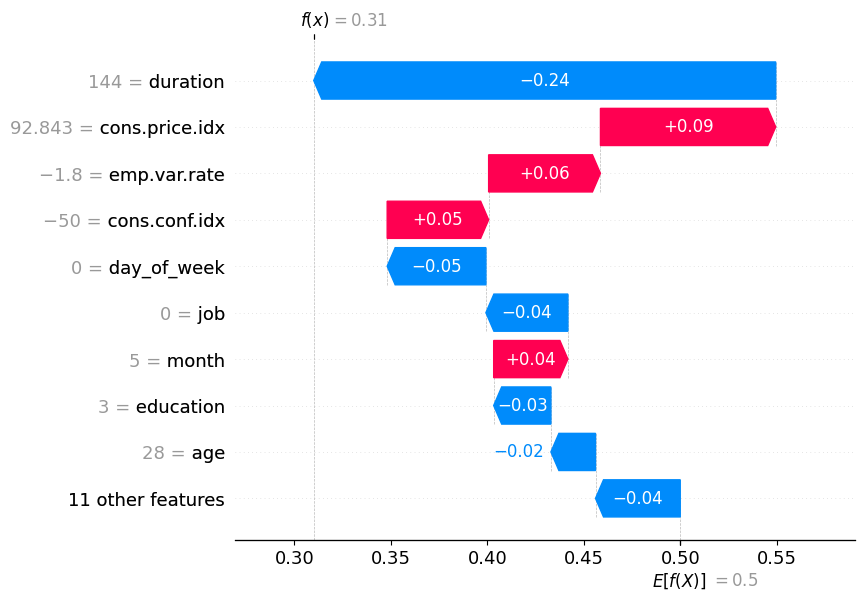

In [18]:
# ── STEP 10: EXPLAIN 5 INDIVIDUAL PREDICTIONS 
# Waterfall plot shows exactly WHY model predicted yes/no for one person

print("Explaining 5 individual predictions...\n")

for i in range(5):
    print(f"--- Customer #{i+1} ---")
    print(f"Actual:    {'YES' if y_test.iloc[i] == 1 else 'NO'}")
    print(f"Predicted: {'YES' if y_pred_rf[i] == 1 else 'NO'}")

    # Force plot for individual prediction
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[i, :, 1],
            base_values=explainer.expected_value[1],
            data=X_test_df.iloc[i],
            feature_names=X.columns.tolist()
        )
    )
    print()